# Tensor Flow

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [15]:
# Sample data
data = {
    'Size': [50, 60, 70, 80, 90],
    'Price': [150, 180, 210, 240, 270]
}

df = pd.DataFrame(data)
df

#spit
X= df[['Size']] #feature
y= df['Price'] #target

#split into train and test sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#initialize the train model
model = LinearRegression()
model.fit(X_train,y_train)

#Make predictions
y_pred=model.predict(X_test)

print("Actual:",y_test.values)
print("Prediction:",y_pred)



Actual: [180]
Prediction: [180.]


MSE → how wrong your predictions are (lower is better)

R2 → how well your model explains variance (1 = perfect)

In [17]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MSE: ",mse)
print("R2: ",r2)


MSE:  0.0
R2:  nan


/Users/puspo/MLPython/PyCharmMiscProject/venv_tf/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


 - Linear Regression
 - Logistic Regression (for classification)
 - Decision Trees / Random Forest
 - KNN (K-Nearest Neighbors)
 - SVM (Support Vector Machine)
 - Clustering (K-Means, DBSCAN)

## Introduction to Tensorflow -> Deep Learning -> simple neural network for regression

- Sequential() → layers stacked linearly
- Dense() → fully connected layer
- compile() → defines optimizer and loss
- fit() → trains the model

In [18]:
model =Sequential([ #Sequential model -> linear stack of layers
    Dense(10,input_dim = 1,activation='relu'), #hidden layer -> 10 nodes which are activated by ReLU -> relu is a function that returns the maximum of 0 and the input value
    Dense(1) #output layer -> 1 node -> linear activation function
])

model.compile(optimizer='adam',loss='mse') #optimizer='adam' -> uses the Adam optimization algorithm -> it's a variant of stochastic gradient descent that's well-suited for deep learning

model.fit(X_train,y_train,epochs=100, verbose=0) #epochs=100 -> number of times the model will iterate over the entire training dataset

y_pred_tf = model.predict(X_test)
print("Predictions from TensorFlow:", y_pred_tf.flatten())

/Users/puspo/MLPython/PyCharmMiscProject/venv_tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predictions from TensorFlow: [33.788914]


## Visualization

AttributeError: Line2D.set() got an unexpected keyword argument 'lineStyle'

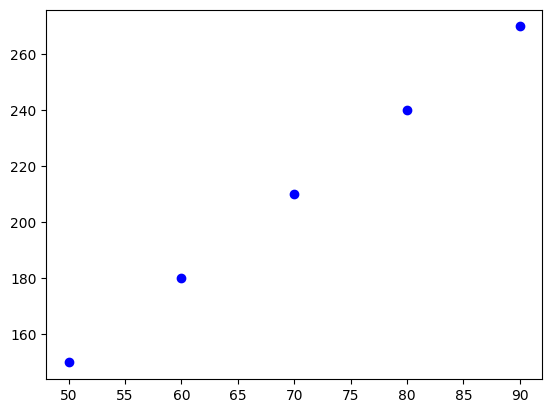

In [ ]:
from cProfile import label
plt.scatter(X,y,color = 'blue')
plt.plot(X_test,y_pred,color='red',label ='Linear Regression')
plt.plot(X_test,y_pred_tf,color='green',linestyle='--',label='Neural Network')
plt.legend()
plt.show()